In [1]:
#Step 1: Create the SQLite Database (sales_data.db)

import sqlite3

# Connect to or create the database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create the 'sales' table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

# Insert sample data (we run only once other wise duplicate rows insert)
sample_data = [
    ('Pen', 10, 5.0),
    ('Notebook', 5, 20.0),
    ('Eraser', 15, 2.0),
    ('Pen', 8, 5.0),
    ('Notebook', 2, 20.0),
    ('Eraser', 10, 2.0)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()
conn.close()


In [2]:
#Step 2: Run SQL Query & Load into Pandas

import pandas as pd

# Reconnect to database
conn = sqlite3.connect("sales_data.db")

# SQL to get total quantity and revenue per product
query = '''
    SELECT product, 
           SUM(quantity) AS total_qty, 
           SUM(quantity * price) AS revenue 
    FROM sales 
    GROUP BY product
'''

# Load data into pandas
df = pd.read_sql_query(query, conn)
conn.close()

# Display result
print(df)
df


    product  total_qty  revenue
0    Eraser         25     50.0
1  Notebook          7    140.0
2       Pen         18     90.0


,product,total_qty,revenue
0,Eraser,25,50.0
1,Notebook,7,140.0
2,Pen,18,90.0


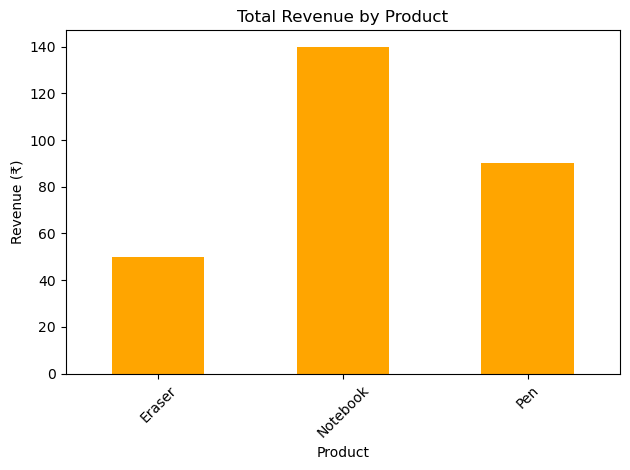

In [4]:
Step 3: Visualize the Results with Bar Chart

import matplotlib.pyplot as plt

# Plotting with label rotation
ax = df.plot(kind='bar', x='product', y='revenue', color='orange', legend=False)
plt.title("Total Revenue by Product")
plt.ylabel("Revenue (₹)")
plt.xlabel("Product")
plt.xticks(rotation=45)  # Rotate x-axis labels to avoid overlap
plt.tight_layout()
plt.savefig("sales_chart.png")  # Optional: Save chart as image
plt.show()

